In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 01 — Rolling Window Setup

Partitions the processed dataset into chronological time steps (calendar months) and enumerates all valid (Model A, Model B) window pairs for the rolling-retraining experiment.

**Input:** `data/processed/` (from notebook 00)
**Output:** `data/windows/window_config.json`

---

**Framework recap:**
- Data partitioned into time steps D_{t1}, …, D_{tK} (one per calendar month).
- Training window: W_k = D_{t_{k-L+1}} ∪ … ∪ D_{t_k}  (fixed length L months).
- Model A trained on W_k, Model B on W_{k+S}.
- Common evaluation slice: E_{A,B} = D_{t_{k+S+1}} ∪ … ∪ D_{t_{k+S+H}}.
- `PAIR_STRIDE` skips pairs to control runtime; only every PAIR_STRIDE-th valid pair is kept.

**Parameters used:**
| Parameter | Value | Meaning |
|-----------|-------|--------|
| L | 8 | training window length (months) |
| S | 2 | step between Model A and Model B |
| H | 3 | evaluation horizon (months) |
| R | 5 | replicas per window |
| K_FRAC | 0.10 | top fraction of eval instances flagged |
| PAIR_STRIDE | 4 | keep every PAIR_STRIDE-th valid pair |
| MIN_PER_STEP | 50 | minimum rows required for a month to be a valid time step |


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

WORKSPACE = Path('/content/drive/MyDrive/Homesite_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'
WIN_DIR.mkdir(parents=True, exist_ok=True)

# ── Experiment parameters ─────────────────────────────────────────────────
L            = 8     # training window length (months)
S            = 2     # step between A and B
H            = 3     # evaluation horizon (months)
R            = 3     # replicas per window
K_FRAC       = 0.10  # top-K fraction flagged in eval
PAIR_STRIDE  = 4     # keep every PAIR_STRIDE-th valid pair (1 = keep all)
MIN_PER_STEP = 50    # min rows per month for it to count as a valid time step
TIME_UNIT    = 'month'

print(f'L={L}, S={S}, H={H}, R={R}, K_FRAC={K_FRAC}, PAIR_STRIDE={PAIR_STRIDE}, MIN_PER_STEP={MIN_PER_STEP}')

L=8, S=2, H=3, R=3, K_FRAC=0.1, PAIR_STRIDE=4, MIN_PER_STEP=50


## 1. Load processed data

In [3]:
X    = pd.read_parquet(PROC_DIR / 'X.parquet')
Y    = np.load(PROC_DIR / 'Y.npy')
meta = pd.read_parquet(PROC_DIR / 'meta.parquet')

assert len(X) == len(Y) == len(meta)
assert pd.api.types.is_datetime64_any_dtype(meta['quote_date'])

print(f'X    : {X.shape}')
print(f'Y    : {Y.shape}  positives={Y.sum():,} ({Y.mean():.3%})')
print(f'meta : {meta.shape}')
print(f'Date range: {meta["quote_date"].min()} → {meta["quote_date"].max()}')

X    : (260753, 317)
Y    : (260753,)  positives=48,894 (18.751%)
meta : (260753, 6)
Date range: 2013-01-01 00:00:00 → 2015-05-18 00:00:00


## 2. Define time steps (calendar months)

Each row is assigned to the first day of its calendar month. Months with fewer than `MIN_PER_STEP` rows are dropped (they would make rolling windows unreliable).

In [4]:
# Snap to first-of-month so we can sort/compare months as plain Timestamps.
meta['month'] = meta['quote_date'].dt.to_period('M').dt.to_timestamp()

month_counts = meta['month'].value_counts().sort_index()
print('Rows per month:')
print(month_counts.to_string())

Rows per month:
month
2013-01-01     7195
2013-02-01     6744
2013-03-01     7493
2013-04-01     8833
2013-05-01     9413
2013-06-01     9798
2013-07-01    11241
2013-08-01    11272
2013-09-01    10245
2013-10-01    10148
2013-11-01     6336
2013-12-01     5740
2014-01-01    11270
2014-02-01     9909
2014-03-01    12008
2014-04-01     9585
2014-05-01     9124
2014-06-01    10091
2014-07-01     9542
2014-08-01     8274
2014-09-01     8067
2014-10-01     7860
2014-11-01     7432
2014-12-01     6945
2015-01-01     9755
2015-02-01     7897
2015-03-01    12241
2015-04-01    10205
2015-05-01     6090


In [5]:
# Filter out under-populated months — they would otherwise produce unstable windows.
valid_months = month_counts[month_counts >= MIN_PER_STEP].index
time_steps   = sorted(valid_months.tolist())
K = len(time_steps)

print(f'\nValid time steps (K) : {K}')
print(f'First step           : {time_steps[0].date()}')
print(f'Last step            : {time_steps[-1].date()}')


Valid time steps (K) : 29
First step           : 2013-01-01
Last step            : 2015-05-01


In [6]:
# Map each row to its time-step index. Rows in dropped months get -1 and are
# excluded from every window.
ts_to_idx = {ts: i for i, ts in enumerate(time_steps)}
meta['step_idx'] = meta['month'].map(ts_to_idx).fillna(-1).astype(int)

# Pre-compute a {step_idx -> row positions} dictionary; this is the only structure
# downstream cells need to slice X / Y by time step.
rows_by_step = {
    i: meta.index[meta['step_idx'] == i].to_numpy(dtype=np.int64)
    for i in range(K)
}

valid = meta['step_idx'] >= 0
print(f'Rows assigned to a valid step : {valid.sum():,} / {len(meta):,}')
print(f'Rows in dropped months        : {(~valid).sum():,}')

Rows assigned to a valid step : 260,753 / 260,753
Rows in dropped months        : 0


## 3. Enumerate valid window pairs

A pair is valid when:
- Window A spans steps [k-L+1 … k]
- Window B spans steps [k+S-L+1 … k+S]
- Evaluation slice spans steps [k+S+1 … k+S+H]
- All three lie inside [0, K-1]

`PAIR_STRIDE` then keeps only every PAIR_STRIDE-th of these.

In [7]:
def get_indices(step_idxs):
    """Concatenate row indices belonging to a list of step indices."""
    if not step_idxs:
        return np.array([], dtype=np.int64)
    return np.concatenate([rows_by_step[i] for i in step_idxs])


pairs_all = []
for k in range(K):
    a_steps = list(range(k - L + 1, k + 1))            # window A: L steps ending at k
    b_steps = list(range(k + S - L + 1, k + S + 1))    # window B: L steps ending at k+S
    e_steps = list(range(k + S + 1, k + S + H + 1))    # eval: H steps after window B

    if a_steps[0] < 0 or e_steps[-1] >= K:
        continue

    idx_A    = get_indices(a_steps)
    idx_B    = get_indices(b_steps)
    idx_eval = get_indices(e_steps)

    if len(idx_A) == 0 or len(idx_B) == 0 or len(idx_eval) == 0:
        continue

    pairs_all.append({
        'pair_id':           len(pairs_all),         # provisional; renumbered after stride
        'k':                 k,
        'A_steps':           a_steps,
        'B_steps':           b_steps,
        'eval_steps':        e_steps,
        'step_label_A':      time_steps[a_steps[-1]].strftime('%Y-%m'),
        'step_label_B':      time_steps[b_steps[-1]].strftime('%Y-%m'),
        'eval_start_label':  time_steps[e_steps[0]].strftime('%Y-%m'),
        'eval_end_label':    time_steps[e_steps[-1]].strftime('%Y-%m'),
        'idx_A':              idx_A.tolist(),
        'idx_B':              idx_B.tolist(),
        'idx_eval':           idx_eval.tolist(),
        'n_train_A':          int(len(idx_A)),
        'n_train_B':          int(len(idx_B)),
        'n_eval':             int(len(idx_eval)),
    })

# Apply PAIR_STRIDE and renumber pair_id contiguously from 0.
pairs = pairs_all[::PAIR_STRIDE]
for new_id, p in enumerate(pairs):
    p['pair_id'] = new_id

print(f'Valid pairs (before stride) : {len(pairs_all)}')
print(f'Valid pairs (after stride)  : {len(pairs)}')

Valid pairs (before stride) : 17
Valid pairs (after stride)  : 5


In [8]:
# Compact summary for inspection.
summary = pd.DataFrame([
    {
        'pair_id':       p['pair_id'],
        'A_end':         p['step_label_A'],
        'B_end':         p['step_label_B'],
        'eval_start':    p['eval_start_label'],
        'eval_end':      p['eval_end_label'],
        'n_train_A':     p['n_train_A'],
        'n_train_B':     p['n_train_B'],
        'n_eval':        p['n_eval'],
    }
    for p in pairs
])
print(summary.to_string(index=False))

 pair_id   A_end   B_end eval_start eval_end  n_train_A  n_train_B  n_eval
       0 2013-08 2013-10    2013-11  2014-01      71989      78443   23346
       1 2013-12 2014-02    2014-03  2014-05      74193      76161   30717
       2 2014-04 2014-06    2014-07  2014-09      75241      74063   25883
       3 2014-08 2014-10    2014-11  2015-01      79803      74551   24132
       4 2014-12 2015-02    2015-03  2015-05      67335      65772   28536


## 4. Verify non-overlap of evaluation slices

In [9]:
# Eval slice must never overlap the training windows of its own pair, and the
# A/B windows themselves should not share rows with eval.
for p in pairs:
    set_A = set(p['idx_A'])
    set_B = set(p['idx_B'])
    set_E = set(p['idx_eval'])
    assert set_A.isdisjoint(set_E), f'Pair {p["pair_id"]}: A overlaps eval'
    assert set_B.isdisjoint(set_E), f'Pair {p["pair_id"]}: B overlaps eval'

print('All pair leakage checks passed.')

All pair leakage checks passed.


## 5. Save window configuration

The JSON captures everything needed to reproduce the experiment downstream:
- `parameters` — scalar hyperparameters and the ordered list of month labels that define the time axis.
- `pairs` — one entry per valid (A, B) pair, each containing pre-computed row index lists usable directly with `.iloc` on X and Y.

In [10]:
config = {
    'parameters': {
        'L':            L,
        'S':            S,
        'H':            H,
        'R':            R,
        'K_FRAC':       K_FRAC,
        'PAIR_STRIDE':  PAIR_STRIDE,
        'MIN_PER_STEP': MIN_PER_STEP,
        'TIME_UNIT':    TIME_UNIT,
        'K':            K,
        'time_steps':   [ts.strftime('%Y-%m-%d') for ts in time_steps],
    },
    'pairs': pairs,
}

out_path = WIN_DIR / 'window_config.json'
with open(out_path, 'w') as f:
    json.dump(config, f, indent=2)

size_kb = out_path.stat().st_size / 1024
print(f'Saved {out_path.name} ({size_kb:.0f} KB)')
print(f'{len(pairs)} window pairs, {K} time steps')

Saved window_config.json (13283 KB)
5 window pairs, 29 time steps


## 6. Visual diagnostics

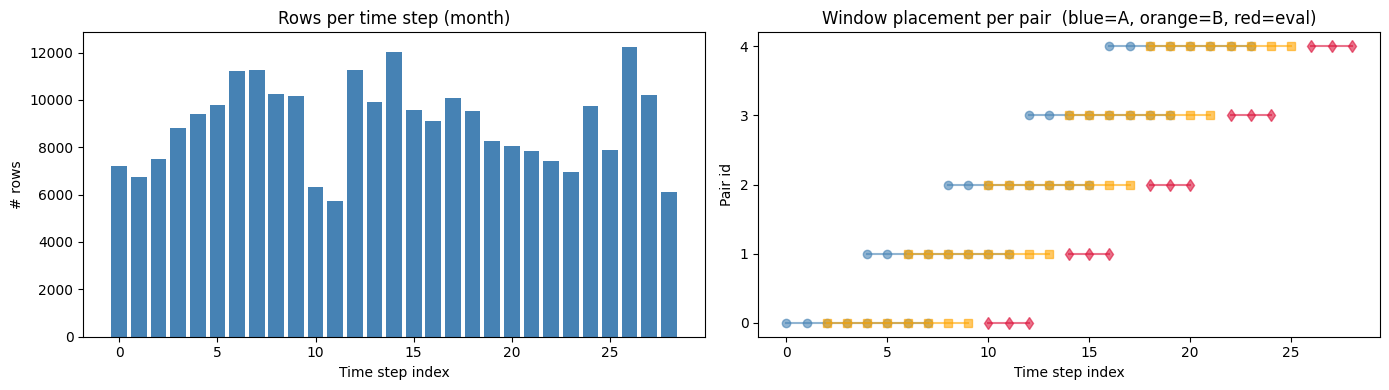

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Volume per time step
axes[0].bar(range(K), [len(rows_by_step[i]) for i in range(K)], color='steelblue')
axes[0].set_title(f'Rows per time step ({TIME_UNIT})')
axes[0].set_xlabel('Time step index')
axes[0].set_ylabel('# rows')

# Window placement timeline
for p in pairs:
    pid = p['pair_id']
    axes[1].plot(p['A_steps'], [pid] * L, 'o-', color='steelblue', alpha=0.6)
    axes[1].plot(p['B_steps'], [pid] * L, 's-', color='orange', alpha=0.6)
    axes[1].plot(p['eval_steps'], [pid] * H, 'd-', color='crimson', alpha=0.6)

axes[1].set_title('Window placement per pair  (blue=A, orange=B, red=eval)')
axes[1].set_xlabel('Time step index')
axes[1].set_ylabel('Pair id')
axes[1].set_yticks(range(len(pairs)))

plt.tight_layout()
plt.show()